# LinkedIn Job Market Analysis
## Step 1 — Python: Load, Clean & Explore the Data

**What we do in this notebook:**
1. Load the 3 CSV files
2. Explore what the data looks like
3. Clean the data (fix nulls, duplicates, salary)
4. Merge the files together
5. Save the cleaned data for SQL (Step 2)
6. Create basic charts for all 5 business questions

---
## PART 1 — Install & Import Libraries

Libraries are like toolboxes. We import them so Python knows which tools we want to use.

In [ ]:
# Run this only once to install libraries if you don't have them
# !pip install pandas matplotlib seaborn

In [1]:
import pandas as pd          # pandas  → for loading and cleaning data (like Excel but in Python)
import matplotlib.pyplot as plt  # matplotlib → for drawing charts and graphs
import seaborn as sns        # seaborn  → makes matplotlib charts look nicer
import warnings
warnings.filterwarnings('ignore')  # hides unnecessary warning messages

# This line makes charts appear inside the notebook (not in a separate window)
%matplotlib inline

print('All libraries imported successfully!')

All libraries imported successfully!


---
## PART 2 — Load the 3 CSV Files

`pd.read_csv()` reads a CSV file and turns it into a **DataFrame**.
Think of a DataFrame as a table — just like a spreadsheet with rows and columns.

In [2]:
# Load the 3 CSV files from your raw data folder
# Make sure these file paths match where you saved the CSVs

postings  = pd.read_csv('../data/raw/postings.csv', low_memory=False)
skills    = pd.read_csv('../data/raw/job_skills.csv')
companies = pd.read_csv('../data/raw/companies.csv', low_memory=False)

print('postings.csv  →', postings.shape[0],  'rows,', postings.shape[1],  'columns')
print('job_skills.csv →', skills.shape[0],   'rows,', skills.shape[1],   'columns')
print('companies.csv  →', companies.shape[0], 'rows,', companies.shape[1], 'columns')

postings.csv  → 123849 rows, 31 columns
job_skills.csv → 213768 rows, 2 columns
companies.csv  → 24473 rows, 10 columns


---
## PART 3 — Explore the Raw Data

Before cleaning, we always **look at** the data first.
This helps us understand what columns we have and what problems exist.

In [3]:
# .head() shows the first 5 rows of the table
# This is how we take a quick peek at the data

print('=== First 5 rows of postings.csv ===')
postings.head()

=== First 5 rows of postings.csv ===


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [4]:
# .info() tells us:
#  - column names
#  - how many non-null (non-empty) values each column has
#  - the data type of each column (int, float, object/text)

print('=== postings.csv — column info ===')
postings.info()

=== postings.csv — column info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non

In [ ]:
# isnull().sum() counts how many EMPTY (missing) values are in each column
# Empty values = NaN = "Not a Number" — they are blanks in the data

print('=== Missing values in postings.csv ===')
print(postings.isnull().sum())



=== Missing values in postings.csv ===
job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0

In [11]:
print('=== Missing values in company.csv ===')
print(companies.isnull().sum())

=== Missing values in company.csv ===
company_id         0
name               1
description      297
company_size    2774
state             22
country            0
city               1
zip_code          28
address           22
url                0
dtype: int64


In [13]:
# .duplicated().sum() counts how many rows are exact duplicates
# Duplicate rows = same job posted twice = we need to remove them

print('Duplicate rows in postings:', postings.duplicated().sum())
print('Duplicate rows in skills:  ', skills.duplicated().sum())
print('Duplicate rows in companies:', companies.duplicated().sum())

Duplicate rows in postings: 0
Duplicate rows in skills:   0
Duplicate rows in companies: 0


In [14]:
# Let's see all the column names in postings.csv
# We'll use only the columns relevant to our 5 business questions

print('All columns in postings.csv:')
print(list(postings.columns))

All columns in postings.csv:
['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


In [22]:
job_industries = pd.read_csv('../data/raw/job_industries.csv')
print(job_industries.columns.tolist())
print(job_industries.head())

['job_id', 'industry_id']
       job_id  industry_id
0  3884428798           82
1  3887473071           48
2  3887465684           41
3  3887467939           82
4  3887467939           80


In [25]:
industries = pd.read_csv('../data/raw/industries.csv')
print(industries.columns.tolist())
print(industries.head())
print('Total industries:', len(industries))
print('Total job-industry links:', len(job_industries))



print('job_industries shape:', job_industries.shape)
print('industries shape:', industries.shape)

['industry_id', 'industry_name']
   industry_id                         industry_name
0            1       Defense and Space Manufacturing
1            3       Computer Hardware Manufacturing
2            4                  Software Development
3            5          Computer Networking Products
4            6  Technology, Information and Internet
Total industries: 422
Total job-industry links: 164808
job_industries shape: (164808, 2)
industries shape: (422, 2)


---
## PART 4 — Select Only the Columns We Need

The dataset has many columns. We only keep the ones that help answer our 5 business questions.
This makes the data smaller and easier to work with.

In [15]:
# We select only these columns from postings.csv
# Each column answers a specific business question:

postings_clean = postings[[
    'job_id',           # unique ID for each job — used to join with skills table
    'company_id',       # unique ID for each company — used to join with companies table
    'title',            # job title → BQ1: Most in-demand job titles
    'location',         # city/state → BQ2: Which cities have most openings
    'work_type',        # Remote/Onsite/Hybrid → BQ3: Work type ratio
    'formatted_experience_level',  # Entry/Mid/Senior → BQ4: Salary by experience
    'max_salary',       # salary info → BQ4: Average salary by experience
    'min_salary',       # salary info → BQ4: Average salary by experience
    'med_salary',       # median salary → BQ4 backup if max/min are missing
    'pay_period',       # HOURLY or YEARLY — important for salary calculation
]].copy()  # .copy() creates a fresh copy so we don't accidentally modify the original

print('Columns selected:', list(postings_clean.columns))
print('Shape:', postings_clean.shape)

Columns selected: ['job_id', 'company_id', 'title', 'location', 'work_type', 'formatted_experience_level', 'max_salary', 'min_salary', 'med_salary', 'pay_period']
Shape: (123849, 10)


In [24]:
# Select only what we need from companies.csv
# industry column → BQ5: Which industries hire most analysts

companies_clean = companies[[
    'company_id',   # used to join/merge with postings
    'name',         # company name
]]

print('Companies columns selected:', list(companies_clean.columns))

Companies columns selected: ['company_id', 'name']


In [28]:
industry_mapped = job_industries.merge(industries,on='industry_id',how='left')

print('industry_mapped shape:', industry_mapped.shape)
print(industry_mapped.head())

print(postings_clean.duplicated().sum())

industry_mapped shape: (164808, 3)
       job_id  industry_id                   industry_name
0  3884428798           82  Book and Periodical Publishing
1  3887473071           48                    Construction
2  3887465684           41                         Banking
3  3887467939           82  Book and Periodical Publishing
4  3887467939           80            Advertising Services
0


---
## PART 5 — Clean the Data

Cleaning = fixing problems in the data so our analysis is accurate.
The 3 most common problems are: **missing values, duplicates, and wrong data types**.

In [32]:
# STEP 5A — Remove duplicate rows
# drop_duplicates() removes any row that is an exact copy of another row

before = len(postings_clean)
postings_clean = postings_clean.drop_duplicates()
after = len(postings_clean)

print(f'Rows before: {before}')
print(f'Rows after removing duplicates: {after}')
print(f'Duplicates removed: {before - after}')



Rows before: 123849
Rows after removing duplicates: 123849
Duplicates removed: 0


In [30]:
# STEP 5B — Drop rows where job_id or title is missing
# These are the most critical columns — a job without a title is useless
# dropna(subset=[...]) removes rows where these specific columns are empty

postings_clean = postings_clean.dropna(subset=['job_id', 'title'])
print('Rows after dropping missing job_id/title:', len(postings_clean))

Rows after dropping missing job_id/title: 123849


In [33]:
# STEP 5C — Clean the title column
# .str.strip() removes extra spaces at the beginning and end → "  Data Analyst  " → "Data Analyst"
# .str.title() capitalizes the first letter of each word → "data analyst" → "Data Analyst"

postings_clean['title'] = postings_clean['title'].str.strip().str.title()

print('Sample job titles after cleaning:')
print(postings_clean['title'].head(10).tolist())

Sample job titles after cleaning:
['Marketing Coordinator', 'Mental Health Therapist/Counselor', 'Assitant Restaurant Manager', 'Senior Elder Law / Trusts And Estates Associate Attorney', 'Service Technician', 'Economic Development And Planning Intern', 'Producer', 'Building Engineer', 'Respiratory Therapist', 'Worship Leader']


In [34]:
# STEP 5D — Extract city from location column
# Location column looks like: "New York, NY" or "San Francisco, CA, United States"
# We split by comma and take the first part to get just the city name

postings_clean['city'] = (
    postings_clean['location']
    .str.split(',')          # split the string at every comma → ['New York', ' NY']
    .str[0]                  # take the first part → 'New York'
    .str.strip()             # remove extra spaces
)

print('Sample cities extracted:')
print(postings_clean['city'].head(10).tolist())

Sample cities extracted:
['Princeton', 'Fort Collins', 'Cincinnati', 'New Hyde Park', 'Burlington', 'Raleigh', 'United States', 'San Francisco', 'Omaha', 'Palm Bay']


In [35]:
# STEP 5E — Clean the work_type column
# Fill missing work_type with 'Unknown' so we don't lose those rows entirely
# .fillna() replaces NaN (empty) values with whatever you put inside

postings_clean['work_type'] = postings_clean['work_type'].fillna('Unknown')

print('Work type values:')
print(postings_clean['work_type'].value_counts())

Work type values:
work_type
FULL_TIME     98814
CONTRACT      12117
PART_TIME      9696
TEMPORARY      1190
INTERNSHIP      983
VOLUNTEER       562
OTHER           487
Name: count, dtype: int64


In [36]:
# STEP 5F — Fix salary columns
# The salary data has 3 columns: min_salary, max_salary, med_salary
# We create ONE clean salary column:
#   → use med_salary if available
#   → else calculate average of min and max
#   → convert HOURLY to YEARLY (hourly * 40 hours * 52 weeks)

def calculate_annual_salary(row):
    # Step 1: pick the best salary value
    if pd.notna(row['med_salary']):
        salary = row['med_salary']        # prefer median salary
    elif pd.notna(row['min_salary']) and pd.notna(row['max_salary']):
        salary = (row['min_salary'] + row['max_salary']) / 2  # average of min and max
    elif pd.notna(row['max_salary']):
        salary = row['max_salary']
    elif pd.notna(row['min_salary']):
        salary = row['min_salary']
    else:
        return None  # no salary data at all → return empty

    # Step 2: convert hourly to annual
    if row['pay_period'] == 'HOURLY':
        salary = salary * 40 * 52  # 40 hours/week × 52 weeks/year

    return round(salary, 2)  # round to 2 decimal places

# Apply the function to every row in the table
# axis=1 means apply row by row (not column by column)
postings_clean['annual_salary'] = postings_clean.apply(calculate_annual_salary, axis=1)

print('Salary stats after cleaning:')
print(postings_clean['annual_salary'].describe())

Salary stats after cleaning:
count    3.607300e+04
mean     2.036471e+05
std      5.097618e+06
min      0.000000e+00
25%      5.000000e+04
50%      8.000000e+04
75%      1.248000e+05
max      5.356000e+08
Name: annual_salary, dtype: float64


In [38]:
postings_clean.head()

,job_id,company_id,title,location,work_type,formatted_experience_level,max_salary,min_salary,med_salary,pay_period,city,annual_salary
0,921716,2774458.0,Marketing Coordinator,"Princeton, NJ",FULL_TIME,NaN,20.0,17.0,NaN,HOURLY,Princeton,38480.0
1,1829192,NaN,Mental Health Therapist/Counselor,"Fort Collins, CO",FULL_TIME,NaN,50.0,30.0,NaN,HOURLY,Fort Collins,83200.0
2,10998357,64896719.0,Assitant Restaurant Manager,"Cincinnati, OH",FULL_TIME,NaN,65000.0,45000.0,NaN,YEARLY,Cincinnati,55000.0
3,23221523,766262.0,Senior Elder Law / Trusts And Estates Associat...,"New Hyde Park, NY",FULL_TIME,NaN,175000.0,140000.0,NaN,YEARLY,New Hyde Park,157500.0
4,35982263,NaN,Service Technician,"Burlington, IA",FULL_TIME,NaN,80000.0,60000.0,NaN,YEARLY,Burlington,70000.0


In [40]:
# STEP 5G — Remove unrealistic salary values
# Some rows have $0 or $10 million salaries — these are data entry errors
# We keep only salaries between $20,000 and $500,000 per year

salary_mask = (
    postings_clean['annual_salary'].isna() |   # keep rows with no salary (don't delete them)
    ((postings_clean['annual_salary'] >= 20000) &   # keep if salary >= 20k
     (postings_clean['annual_salary'] <= 500000))   # keep if salary <= 500k
)

postings_clean = postings_clean[salary_mask]
print('Rows after removing unrealistic salaries:', len(postings_clean))

Rows after removing unrealistic salaries: 122617


In [41]:
# STEP 5H — Clean experience level column
# Fill missing experience levels with 'Not Specified'

postings_clean['formatted_experience_level'] = (
    postings_clean['formatted_experience_level'].fillna('Not Specified')
)

print('Experience level values:')
print(postings_clean['formatted_experience_level'].value_counts())

Experience level values:
formatted_experience_level
Mid-Senior level    40922
Entry level         36428
Not Specified       29176
Associate            9721
Director             3728
Internship           1427
Executive            1215
Name: count, dtype: int64


---
## PART 6 — Merge the 3 Tables Together

Right now we have 3 separate tables. We need to **join** them like a VLOOKUP in Excel.
- `postings` + `companies` → joined by `company_id` (to add industry info)
- `postings` + `skills` → joined by `job_id` (to add skills info)

In [ ]:
# Merge postings with companies using company_id as the KEY
# how='left' means: keep ALL rows from postings, add company info where available
# Think of it like VLOOKUP in Excel — matching on company_id

df = postings_clean.merge(
    companies_clean,
    on='company_id',   # the common column between the two tables
    how='left'         # keep all jobs even if company info is missing
)


print('After merging with companies:')
print('Shape:', df.shape)
df.head(3)

df = df.merge(industry_mapped, on='job_id', how='left')

print('After merging industry:')
print(df.columns.tolist())

df = df.rename(columns={'industry_name': 'industry'})
df = df.drop(columns=['industry_id'])

print(df.columns.tolist())

df = df.drop_duplicates(subset='job_id', keep='first')

print('Total rows after removing duplicate industries:', len(df))
print('Unique job_ids:', df['job_id'].nunique())

After merging with companies:
Shape: (122617, 13)
After merging industry:
['job_id', 'company_id', 'title', 'location', 'work_type', 'formatted_experience_level', 'max_salary', 'min_salary', 'med_salary', 'pay_period', 'city', 'annual_salary', 'name', 'industry_id', 'industry_name']
['job_id', 'company_id', 'title', 'location', 'work_type', 'formatted_experience_level', 'max_salary', 'min_salary', 'med_salary', 'pay_period', 'city', 'annual_salary', 'name', 'industry']


In [43]:
# Now let's also peek at the skills table
# It's a separate table because one job can have MULTIPLE skills
# So we'll keep it separate and use it just for the skills analysis

print('Skills table sample:')
print(skills.head(10))
print('\nUnique jobs in skills table:', skills['job_id'].nunique())

Skills table sample:
       job_id skill_abr
0  3884428798      MRKT
1  3884428798        PR
2  3884428798       WRT
3  3887473071      SALE
4  3887465684       FIN
5  3887465684      SALE
6  3887467939      SALE
7  3887467939      ADVR
8  3887467939        BD
9  3887471331       ENG

Unique jobs in skills table: 126807


---
## PART 7 — Save Cleaned Data

We save the cleaned data to the `data/cleaned/` folder.
These files will be used in Step 2 (SQL) and Step 3 (Excel).

In [101]:
# Save the main merged cleaned file
df.to_csv('../data/cleaned/cleaned_postings.csv', index=False)
# index=False means don't save the row numbers (0,1,2,3...) as a column

# Save the skills table (already clean, just save it)
skills.to_csv('../data/cleaned/cleaned_skills.csv', index=False)

print('Files saved successfully!')
print('cleaned_postings.csv →', len(df), 'rows')
print('cleaned_skills.csv   →', len(skills), 'rows')

Files saved successfully!
cleaned_postings.csv → 122617 rows
cleaned_skills.csv   → 213768 rows


---
## PART 8 — Exploratory Data Analysis (EDA) with Charts

Now the fun part! We create charts for all 5 business questions.
EDA = **Exploring** the data visually to find patterns and insights.

In [88]:
# Chart styling — makes all charts look clean and professional
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)  # default chart size (width=12, height=5 inches)
plt.rcParams['font.size'] = 12

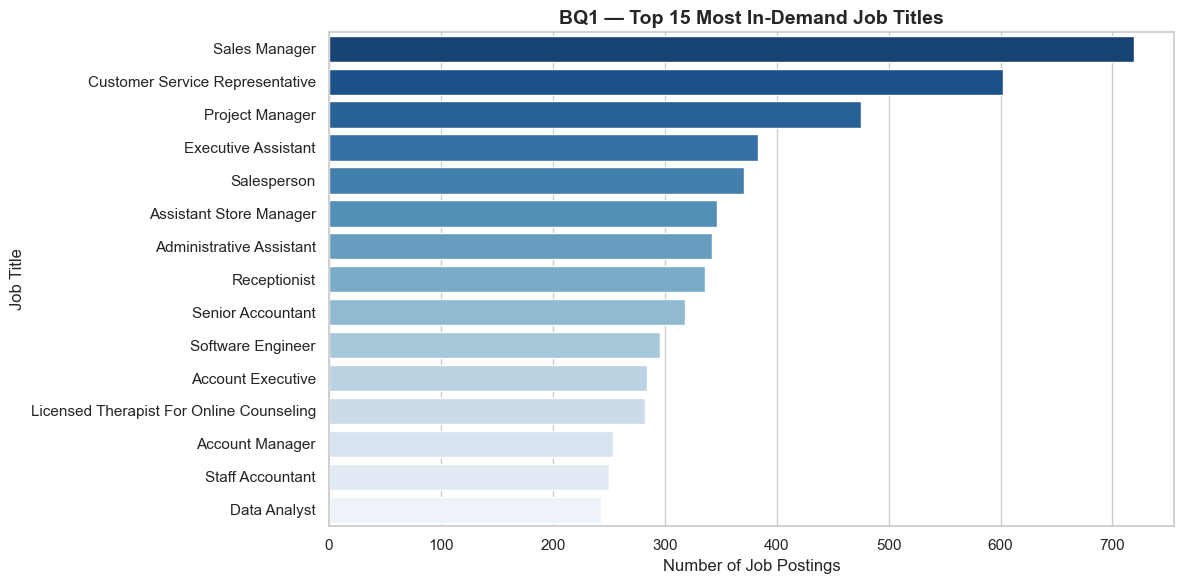

In [89]:
# ============================================================
# BQ1 — Most In-Demand Job Titles
# ============================================================
# value_counts() counts how many times each job title appears
# .head(15) takes the top 15 most common titles

top_titles = df['title'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_titles.values,   # x-axis = count (number of job postings)
    y=top_titles.index,    # y-axis = job title names
    palette='Blues_r'      # color theme (dark to light blue)
)
plt.title('BQ1 — Top 15 Most In-Demand Job Titles', fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Title')
plt.tight_layout()   # adjusts spacing so nothing is cut off
plt.savefig('../data/cleaned/bq1_top_titles.png', dpi=150)  # save the chart as image
plt.show()

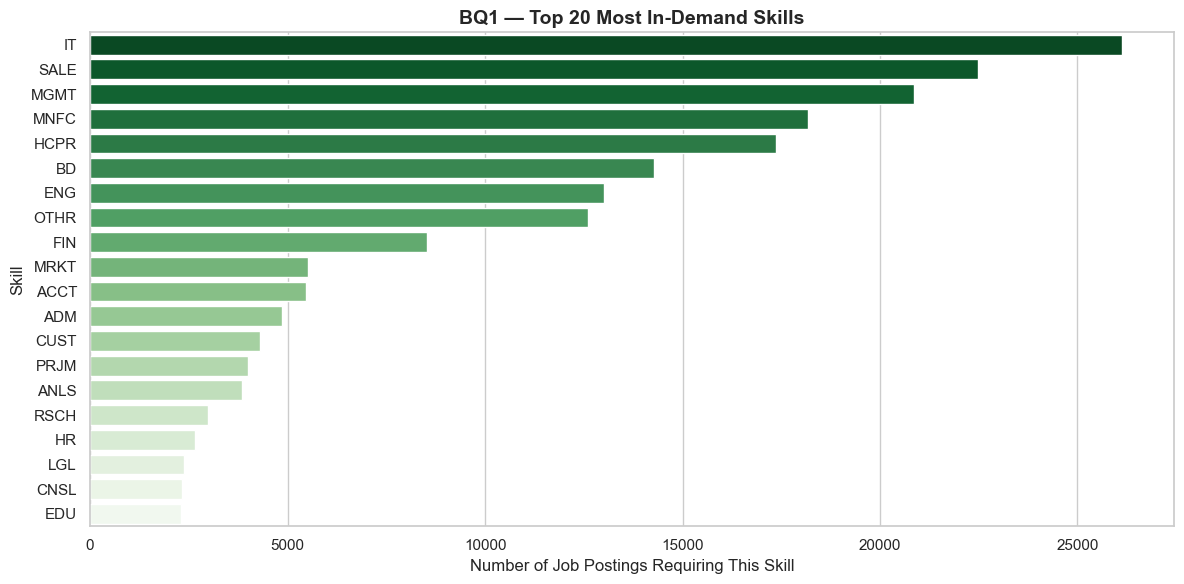

In [90]:
# ============================================================
# BQ1 (Part 2) — Most In-Demand Skills
# ============================================================
# The skills table has a 'skill_abr' column with skill abbreviations
# We count each skill's frequency across all job postings

top_skills = skills['skill_abr'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_skills.values,
    y=top_skills.index,
    palette='Greens_r'
)
plt.title('BQ1 — Top 20 Most In-Demand Skills', fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Postings Requiring This Skill')
plt.ylabel('Skill')
plt.tight_layout()
plt.savefig('../data/cleaned/bq1_top_skills.png', dpi=150)
plt.show()

In [91]:
# ============================================================
# BQ2 — Which Cities Have the Most Data Analyst Openings?
# ============================================================
# First filter to only Data Analyst jobs
# .str.contains() checks if the title contains the word 'analyst' (case-insensitive)

analyst_jobs = df[df['title'].str.contains('analyst', case=False, na=False)]
print('Total analyst job postings:', len(analyst_jobs))

analyst_jobs

Total analyst job postings: 6494


,job_id,company_id,title,location,work_type,formatted_experience_level,max_salary,min_salary,med_salary,pay_period,city,annual_salary,name,industry
77,1880409118,16154524.0,Board Certified Behavior Analyst,"McDonough, GA",FULL_TIME,Not Specified,NaN,NaN,NaN,NaN,McDonough,NaN,Kona Medical Consulting,Hospitals and Health Care
83,2147609785,167757.0,Fp&A Analyst,"Dallas, TX",FULL_TIME,Not Specified,NaN,NaN,NaN,NaN,Dallas,NaN,The Job Network,Staffing and Recruiting
198,3582587683,1317683.0,Accounts Analyst,"Indiana, PA",FULL_TIME,Not Specified,40000.0,30000.0,NaN,YEARLY,Indiana,35000.0,McNaughton Bros. Inc.,Truck Transportation
325,3763494664,96183900.0,Help Desk Analyst,Huntsville-Decatur-Albertville Area,FULL_TIME,Not Specified,NaN,NaN,NaN,NaN,Huntsville-Decatur-Albertville Area,NaN,HAPPI Health,Hospitals and Health Care
338,3773564741,53019.0,Resolution Analyst,"Kalamazoo, MI",PART_TIME,Not Specified,NaN,NaN,NaN,NaN,Kalamazoo,NaN,SalesPage Technologies,Software Development
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158721,3906260905,537246.0,It - Business Analyst Leader(Electric Distribu...,"Oakland, CA",CONTRACT,Mid-Senior level,NaN,NaN,NaN,NaN,Oakland,NaN,Radiansys Inc.,"Oil, Gas, and Mining"
158763,3906261154,88236.0,Peoplesoft Grants Analyst ** 100% Remote **,United States,CONTRACT,Mid-Senior level,NaN,NaN,NaN,NaN,United States,NaN,Amerit Consulting,Higher Education
158764,3906261154,88236.0,Peoplesoft Grants Analyst ** 100% Remote **,United States,CONTRACT,Mid-Senior level,NaN,NaN,NaN,NaN,United States,NaN,Amerit Consulting,Hospitals and Health Care
158765,3906261154,88236.0,Peoplesoft Grants Analyst ** 100% Remote **,United States,CONTRACT,Mid-Senior level,NaN,NaN,NaN,NaN,United States,NaN,Amerit Consulting,Biotechnology Research


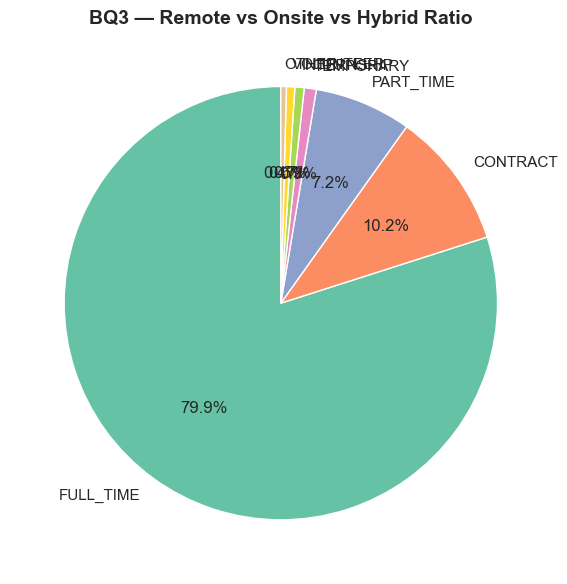

Work type breakdown:
work_type
FULL_TIME     127048
CONTRACT       16224
PART_TIME      11493
TEMPORARY       1426
INTERNSHIP      1100
VOLUNTEER        991
OTHER            654
Name: count, dtype: int64


In [92]:
# ============================================================
# BQ3 — Remote vs Onsite vs Hybrid Ratio
# ============================================================
# A pie chart works best here because we're showing proportions

work_type_counts = df['work_type'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(
    work_type_counts.values,          # the numbers (counts)
    labels=work_type_counts.index,    # the labels (Remote, Onsite, etc.)
    autopct='%1.1f%%',                # show percentage on each slice (e.g. 34.2%)
    startangle=90,                    # rotate chart to start from top
    colors=sns.color_palette('Set2')  # nice distinct colors for each slice
)
plt.title('BQ3 — Remote vs Onsite vs Hybrid Ratio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/cleaned/bq3_work_type.png', dpi=150)
plt.show()

print('Work type breakdown:')
print(work_type_counts)

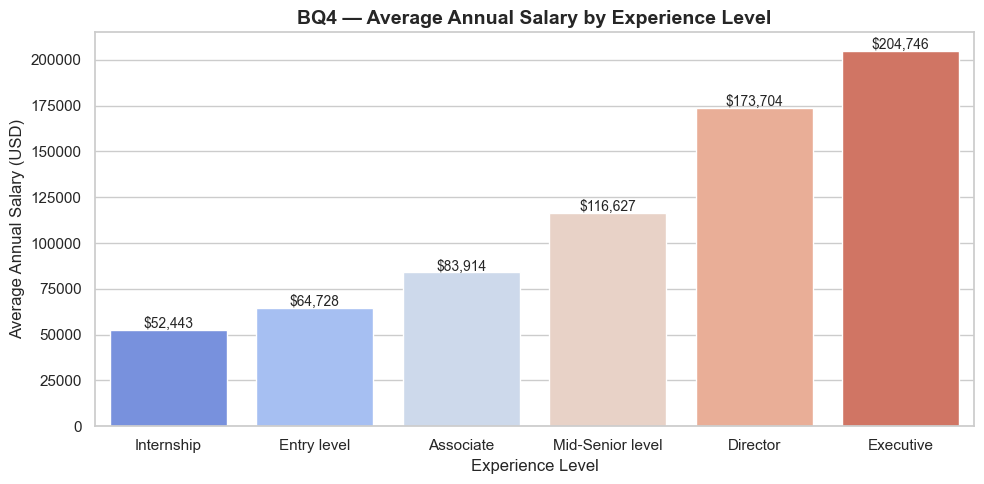

In [93]:
# ============================================================
# BQ4 — Average Salary by Experience Level
# ============================================================
# groupby() groups all rows by experience level
# .mean() then calculates the average salary for each group

# Filter out rows with no salary data and 'Not Specified' experience
salary_df = df[
    df['annual_salary'].notna() &
    (df['formatted_experience_level'] != 'Not Specified')
]

avg_salary = (
    salary_df.groupby('formatted_experience_level')['annual_salary']
    .mean()
    .sort_values()  # sort from lowest to highest salary
    .round(0)       # round to whole numbers
)

plt.figure(figsize=(10, 5))
bars = sns.barplot(
    x=avg_salary.index,    # x-axis = experience level
    y=avg_salary.values,   # y-axis = average salary
    palette='coolwarm'     # cool (blue) for low, warm (red) for high salary
)

# Add salary labels on top of each bar
for bar, value in zip(bars.patches, avg_salary.values):
    bars.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f'${value:,.0f}',
        ha='center', fontsize=10
    )

plt.title('BQ4 — Average Annual Salary by Experience Level', fontsize=14, fontweight='bold')
plt.xlabel('Experience Level')
plt.ylabel('Average Annual Salary (USD)')
plt.tight_layout()
plt.savefig('../data/cleaned/bq4_salary_experience.png', dpi=150)
plt.show()

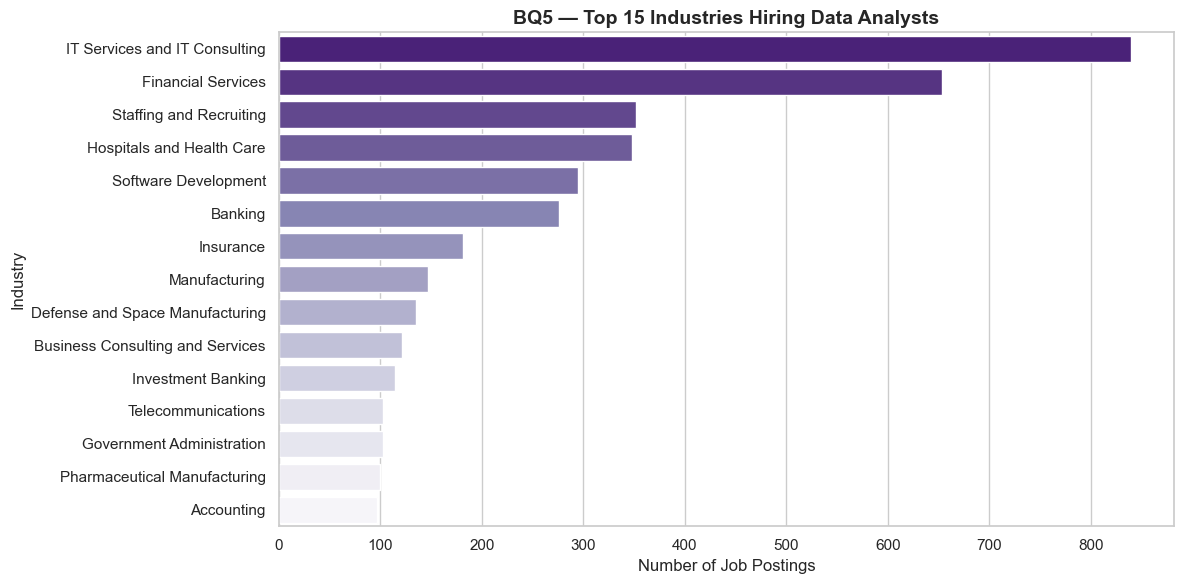

In [95]:
# ============================================================
# BQ5 — Which Industries Hire the Most Analysts?
# ============================================================

# Filter to analyst jobs only and drop rows where industry is missing
industry_df = analyst_jobs[analyst_jobs['industry'].notna()]

top_industries = industry_df['industry'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_industries.values,
    y=top_industries.index,
    palette='Purples_r'
)
plt.title('BQ5 — Top 15 Industries Hiring Data Analysts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Postings')
plt.ylabel('Industry')
plt.tight_layout()
plt.savefig('../data/cleaned/bq5_top_industries.png', dpi=150)
plt.show()

---
## PART 9 — Final Summary

Let's print a clean summary of everything we did in Step 1.

In [68]:
print('=' * 55)
print('   STEP 1 COMPLETE — DATA CLEANING & EDA SUMMARY')
print('=' * 55)
print(f'Total job postings loaded:        {len(postings):>10,}')
print(f'Total job postings after cleaning:{len(df):>10,}')
print(f'Total analyst job postings:       {len(analyst_jobs):>10,}')
print(f'Total skills records:             {len(skills):>10,}')
print(f'Unique cities found:              {df["city"].nunique():>10,}')
print(f'Unique industries found:          {df["industry"].nunique():>10,}')
print(f'Jobs with salary data:            {df["annual_salary"].notna().sum():>10,}')
print('=' * 55)
print()
print('Files saved to data/cleaned/:')
print('  cleaned_postings.csv   → use in Step 2 (SQL)')
print('  cleaned_skills.csv     → use in Step 2 (SQL)')
print('  bq1_top_titles.png     → chart')
print('  bq1_top_skills.png     → chart')
print('  bq2_top_cities.png     → chart')
print('  bq3_work_type.png      → chart')
print('  bq4_salary_experience.png → chart')
print('  bq5_top_industries.png → chart')
print()
print('Next → Step 2: SQL queries in business_queries.sql')

   STEP 1 COMPLETE — DATA CLEANING & EDA SUMMARY
Total job postings loaded:           123,849
Total job postings after cleaning:   122,617
Total analyst job postings:            4,865
Total skills records:                213,768
Unique cities found:                   6,452
Unique industries found:              24,206
Jobs with salary data:                34,841

Files saved to data/cleaned/:
  cleaned_postings.csv   → use in Step 2 (SQL)
  cleaned_skills.csv     → use in Step 2 (SQL)
  bq1_top_titles.png     → chart
  bq1_top_skills.png     → chart
  bq2_top_cities.png     → chart
  bq3_work_type.png      → chart
  bq4_salary_experience.png → chart
  bq5_top_industries.png → chart

Next → Step 2: SQL queries in business_queries.sql


            job_id  company_id  \
0           921716   2774458.0   
1          1829192         NaN   
2         10998357  64896719.0   
3         23221523    766262.0   
4         35982263         NaN   
...            ...         ...   
158931  3906267126   1124131.0   
158932  3906267126   1124131.0   
158933  3906267131  90552133.0   
158934  3906267195   2793699.0   
158935  3906267224     43325.0   

                                                    title  \
0                                   Marketing Coordinator   
1                       Mental Health Therapist/Counselor   
2                             Assitant Restaurant Manager   
3       Senior Elder Law / Trusts And Estates Associat...   
4                                      Service Technician   
...                                                   ...   
158931       Staff Software Engineer, Ml Serving Platform   
158932       Staff Software Engineer, Ml Serving Platform   
158933               Account Executive, Or

Total rows: 158936
Unique job_ids: 122617


In [102]:
print(df.iloc[14])

job_id                                          83789755
company_id                                     3810432.0
title                           Osteogenic Loading Coach
location                                   Anchorage, AK
work_type                                      FULL_TIME
formatted_experience_level                 Not Specified
max_salary                                           NaN
min_salary                                           NaN
med_salary                                           NaN
pay_period                                           NaN
city                                           Anchorage
annual_salary                                        NaN
name                                         OsteoStrong
industry                      Health, Wellness & Fitness
Name: 15, dtype: object


In [104]:
df.head(15)

,job_id,company_id,title,location,work_type,formatted_experience_level,max_salary,min_salary,med_salary,pay_period,city,annual_salary,name,industry
0,921716,2774458.0,Marketing Coordinator,"Princeton, NJ",FULL_TIME,Not Specified,20.0,17.0,NaN,HOURLY,Princeton,38480.0,Corcoran Sawyer Smith,Real Estate
1,1829192,NaN,Mental Health Therapist/Counselor,"Fort Collins, CO",FULL_TIME,Not Specified,50.0,30.0,NaN,HOURLY,Fort Collins,83200.0,NaN,NaN
2,10998357,64896719.0,Assitant Restaurant Manager,"Cincinnati, OH",FULL_TIME,Not Specified,65000.0,45000.0,NaN,YEARLY,Cincinnati,55000.0,The National Exemplar,Restaurants
3,23221523,766262.0,Senior Elder Law / Trusts And Estates Associat...,"New Hyde Park, NY",FULL_TIME,Not Specified,175000.0,140000.0,NaN,YEARLY,New Hyde Park,157500.0,"Abrams Fensterman, LLP",Law Practice
4,35982263,NaN,Service Technician,"Burlington, IA",FULL_TIME,Not Specified,80000.0,60000.0,NaN,YEARLY,Burlington,70000.0,NaN,Facilities Services
5,91700727,1481176.0,Economic Development And Planning Intern,"Raleigh, NC",INTERNSHIP,Not Specified,20.0,14.0,NaN,HOURLY,Raleigh,35360.0,Downtown Raleigh Alliance,Non-profit Organization Management
6,103254301,81942316.0,Producer,United States,CONTRACT,Not Specified,300000.0,60000.0,NaN,YEARLY,United States,180000.0,Raw Cereal,Design Services
7,112576855,NaN,Building Engineer,"San Francisco, CA",FULL_TIME,Not Specified,120000.0,90000.0,NaN,YEARLY,San Francisco,105000.0,NaN,Hospitality
9,1218575,721189.0,Respiratory Therapist,"Omaha, NE",FULL_TIME,Not Specified,NaN,NaN,NaN,NaN,Omaha,NaN,Children's Nebraska,Hospitals and Health Care
10,9615617,1194336.0,Inside Customer Service Associate,"Saginaw, MI",FULL_TIME,Not Specified,NaN,NaN,NaN,NaN,Saginaw,NaN,"Glastender, Inc.",Beverage Manufacturing


In [106]:
skills1=pd.read_csv('../data/raw/job_skills.csv')
skills1.count()

job_id       213768
skill_abr    213768
dtype: int64